📊 数据质量报告
清洗前总数据量：32 条
清洗后有效数据量：32 条
异常/重复数据：0 条
✅ 数据清洗完成，共32条学员记录
所有列名： ['学员 ID', '姓名', '课程科目', '报名日期', '报名课时', '首次缴费', '总续费金额', '是否续费', 'cpa考级等级', '电子学会考级结果', 'CCF-GESP考级结果', '信息素养大赛', '人工智能挑战赛', '学员分类标签', '合计总收入', '报名年份', '报名月份', '首次续费时间', '报名到首续费间隔天数', '累计续费次数', '累计续费总金额', '是否有考级', '是否有参赛', '学员生命周期价值 (LTV)', '学员价值分层', '续费率达标判断', '学员生命周期价值(LTV)']

=== 课程维度营收汇总 ===
+------------+------------+----------------+------------+--------------+-----------+
| 课程科目   |   学员人数 |   首次缴费总额 |   续费总额 |   合计总收入 |   平均LTV |
+============+============+================+============+==============+===========+
| Python     |          5 |           8400 |       9600 |        18000 |   3600    |
+------------+------------+----------------+------------+--------------+-----------+
| c++        |          6 |          11000 |       7800 |        18800 |   3133.33 |
+------------+------------+----------------+------------+--------------+-----------+
| scratch    |         21 |          33800 |      44400 |    

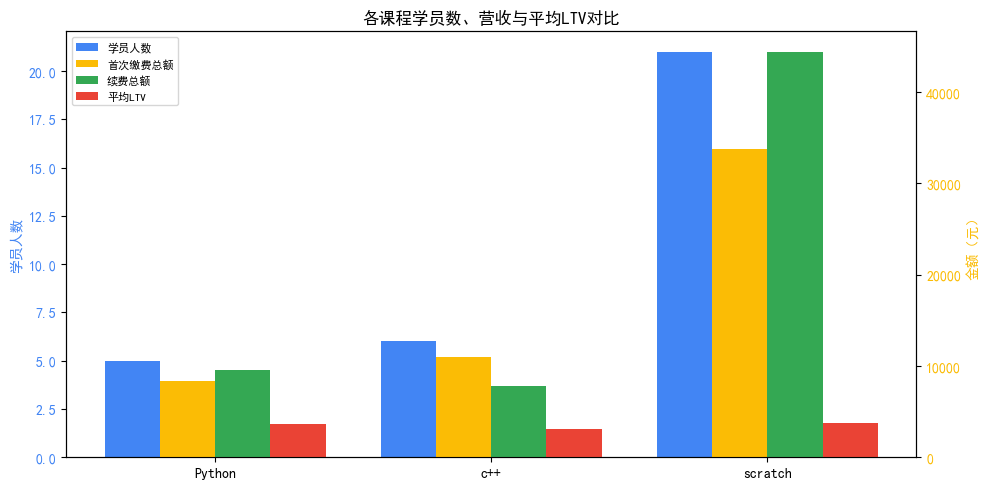


=== 月度经营汇总 ===
+------------+----------------+----------------+--------------+--------------+
| 年月文本   |   当月新签营收 |   当月实收续费 |   月度总营收 | 环比增长率   |
+============+================+================+==============+==============+
| 2025年1月  |           4800 |              0 |         4800 | NaN          |
+------------+----------------+----------------+--------------+--------------+
| 2025年2月  |           5200 |              0 |         5200 | -30.8%       |
+------------+----------------+----------------+--------------+--------------+
| 2025年3月  |           3600 |              0 |         3600 | 0.0%         |
+------------+----------------+----------------+--------------+--------------+
| 2025年4月  |           1200 |           2400 |         3600 | 0.0%         |
+------------+----------------+----------------+--------------+--------------+
| 2025年5月  |           2400 |           1200 |         3600 | 216.7%       |
+------------+----------------+----------------+--------------+---------

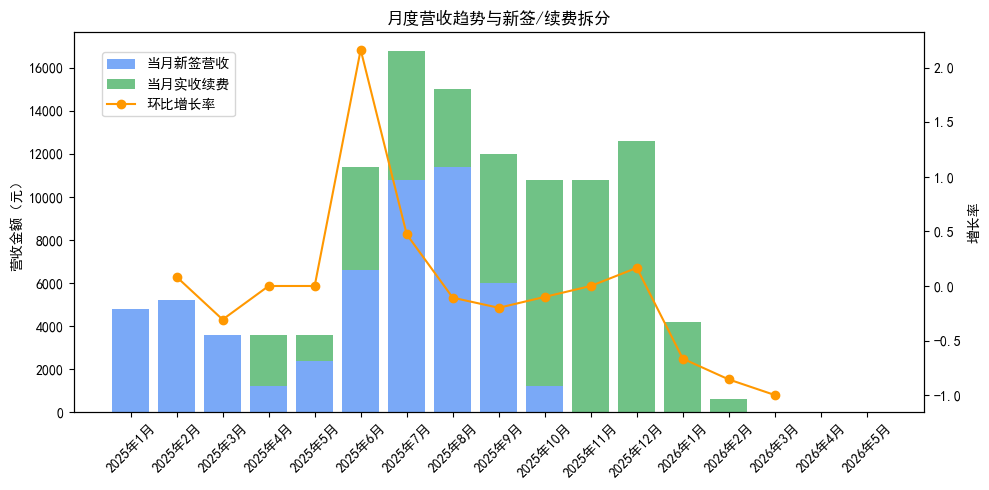


=== 学员价值分层汇总 ===
+----------------+------------+--------------+
| 学员价值分层   |   学员人数 |   合计总收入 |
+================+============+==============+
| 中价值         |         19 |        73800 |
+----------------+------------+--------------+
| 低价值         |         10 |        24000 |
+----------------+------------+--------------+
| 高价值         |          3 |        17200 |
+----------------+------------+--------------+


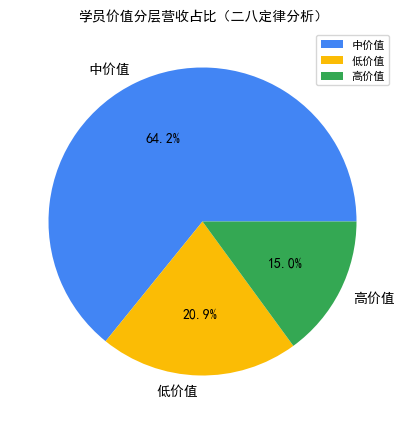


=== 考级/赛事活动效果分析 ===
+--------------+--------------+------------+-----------+--------------------+------------+
| 是否有考级   | 是否有参赛   |   学员人数 |   平均LTV |   平均续费间隔天数 | 活动标签   |
+==============+==============+============+===========+====================+============+
| 否           | 否           |          1 |    2400   |             84     | 否+否      |
+--------------+--------------+------------+-----------+--------------------+------------+
| 是           | 否           |         23 |    3208.7 |            124.174 | 是+否      |
+--------------+--------------+------------+-----------+--------------------+------------+
| 是           | 是           |          8 |    4850   |            115.5   | 是+是      |
+--------------+--------------+------------+-----------+--------------------+------------+


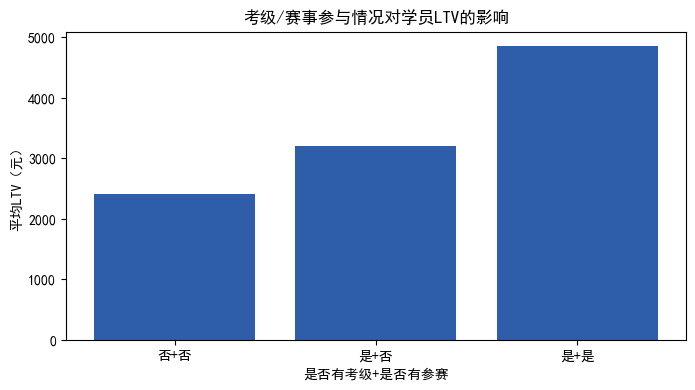


=== 续费留存分析 ===
+------------+------------+-----------+----------------+
| 是否续费   |   学员人数 |   平均LTV |   平均续费次数 |
+============+============+===========+================+
| False      |          3 |   2600    |        0       |
+------------+------------+-----------+----------------+
| True       |         29 |   3696.55 |        1.86207 |
+------------+------------+-----------+----------------+

📌 业务特征工程：衍生学员运营标签

=== 续费潜力学员分布 ===
+----------------+------------+
| 续费潜力等级   |   学员人数 |
+================+============+
| 中续费潜力     |         18 |
+----------------+------------+
| 高续费潜力     |         12 |
+----------------+------------+
| 低续费潜力     |          2 |
+----------------+------------+

=== 学员活跃度分布 ===
+--------------+------------+
| 活跃度等级   |   学员人数 |
+==============+============+
| 活跃学员     |         31 |
+--------------+------------+
| 普通学员     |          1 |
+--------------+------------+

=== 不同续费潜力学员的平均LTV ===
+----------------+-----------+
| 续费潜力等级   |   平均LTV |
+============

In [1]:
# ======================
# 项目名称：教培机构学员营收与留存数据分析
# 版本：v3.0
# 日期：2026-06-03
# 项目背景：基于学员数据，通过多维度分析挖掘营收增长点，为运营策略提供数据支撑
# 分析目标：
# 1. 识别高价值学员特征，优化资源分配
# 2. 分析课程营收贡献，定位主力产品
# 3. 验证考级/赛事活动对学员LTV的提升效果
# 4. 为机构运营策略提供可落地建议
# ======================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

# ----------------------
# 全局配置（统一图表风格，解决中文乱码）
# ----------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 10
COLORS = ["#4285F4", "#FBBC05", "#34A853", "#EA4335"]  # 商务标准配色

def plot_style(figsize=(8, 4)):
    """统一图表样式，保证所有图表风格一致"""
    plt.figure(figsize=figsize)
    plt.tight_layout()

# ======================
# 模块1：数据读取与清洗（与Excel全学员总表1:1对应）
# ======================
file_path = "学生基本信息.xlsx"
df = pd.read_excel(file_path, sheet_name="全学员总表")

# 缺失值处理（与Excel逻辑完全一致）
fill_rules = {
    "cpa考级等级": "无",
    "电子学会考级结果": "无",
    "CCF-GESP考级结果": "无",
    "累计续费总金额": 0,
    "报名到首续费间隔天数": 0,
    "信息素养大赛": "未参赛",
    "人工智能挑战赛": "未参赛"
}
df = df.fillna(fill_rules)

# 日期格式转换（与Excel TEXT函数逻辑对应）
df["报名日期"] = pd.to_datetime(df["报名日期"])
df["报名月份"] = df["报名日期"].dt.to_period("M")
df["报名年份"] = df["报名日期"].dt.year

# 计算核心衍生指标（与Excel LTV/价值分层逻辑对应）
df["合计总收入"] = df["首次缴费"] + df["总续费金额"]
df["学员生命周期价值(LTV)"] = df["合计总收入"]

# 学员价值分层（适配你的数据分布：min=1200, max=3000）
def value_segmentation(row):
    if row["合计总收入"] >= 2400:    # 75%分位数以上，高价值学员
        return "高价值"
    elif row["合计总收入"] >= 1800:  # 中间段，中价值学员
        return "中价值"
    else:                           # 1200-1799，低价值学员
        return "低价值"
df["学员价值分层"] = df.apply(value_segmentation, axis=1)

# 活动参与标记（与Excel考级/赛事逻辑对应）
df["是否有考级"] = np.where(
    (df["cpa考级等级"] != "无") | (df["电子学会考级结果"] != "无") | (df["CCF-GESP考级结果"] != "无"),
    "是", "否"
)
df["是否有参赛"] = np.where(
    (df["信息素养大赛"] != "未参赛") | (df["人工智能挑战赛"] != "未参赛"),
    "是", "否"
)
# ========== 新增：数据质量校验 & 异常处理 ==========
# 1. 去除重复学员数据
df = df.drop_duplicates(subset=["学员 ID"], keep="first")

# 2. 过滤异常数据：营收不能为负、报名日期合规
df = df[(df["合计总收入"] >= 0) & (df["报名日期"] >= "2025-01-01")]

# 3. 输出数据质量报告
total_raw = len(pd.read_excel("学生基本信息.xlsx", sheet_name="全学员总表"))
total_clean = len(df)
print(f"📊 数据质量报告")
print(f"清洗前总数据量：{total_raw} 条")
print(f"清洗后有效数据量：{total_clean} 条")
print(f"异常/重复数据：{total_raw - total_clean} 条")

print("✅ 数据清洗完成，共{}条学员记录".format(len(df)))
print("所有列名：", df.columns.tolist())


# ======================
# 模块2：课程维度多维度营收分析（对应Excel多维度数据透视表）
# ======================
# 分步计算指标（兼容所有Pandas版本，避免agg语法问题）
grouped = df.groupby("课程科目")
student_count = grouped["学员 ID"].count()
first_payment = grouped["首次缴费"].sum()
renew_payment = grouped["总续费金额"].sum()
total_income = grouped["合计总收入"].sum()
avg_ltv = grouped["学员生命周期价值(LTV)"].mean()

# 合并成DataFrame
course_agg = pd.DataFrame({
    "课程科目": student_count.index,
    "学员人数": student_count.values,
    "首次缴费总额": first_payment.values,
    "续费总额": renew_payment.values,
    "合计总收入": total_income.values,
    "平均LTV": avg_ltv.values
})

print("\n=== 课程维度营收汇总 ===")
print(tabulate(course_agg, headers='keys', tablefmt='grid', showindex=False))

# 课程多维度对比柱状图
# （双Y轴版本）
plot_style(figsize=(10, 5))
x = range(len(course_agg["课程科目"]))
width = 0.2

# 1. 第一个Y轴：学员人数（蓝色柱子）
ax1 = plt.gca()
ax1.bar([i - 1.5*width for i in x], course_agg["学员人数"], width, label="学员人数", color=COLORS[0])
ax1.set_ylabel("学员人数", color=COLORS[0])
ax1.tick_params(axis='y', labelcolor=COLORS[0])

# 2. 第二个Y轴：营收数据（黄色/绿色/红色柱子）
ax2 = ax1.twinx()
ax2.bar([i - 0.5*width for i in x], course_agg["首次缴费总额"], width, label="首次缴费总额", color=COLORS[1])
ax2.bar([i + 0.5*width for i in x], course_agg["续费总额"], width, label="续费总额", color=COLORS[2])
ax2.bar([i + 1.5*width for i in x], course_agg["平均LTV"], width, label="平均LTV", color=COLORS[3])
ax2.set_ylabel("金额（元）", color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])

# 3. 合并图例
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left", fontsize=8)

plt.xticks(x, course_agg["课程科目"])
plt.title("各课程学员数、营收与平均LTV对比", fontsize=12)
plt.tight_layout()
plt.show()


# ======================
# 模块3：月度经营看板（对应Excel年度月度经营汇总表）
# ======================
# 1. 直接读取Excel里的年度月度经营汇总表
monthly_agg = pd.read_excel("学生基本信息.xlsx", sheet_name="年度月度经营汇总表")

# 2. 格式化环比增长率为百分比（和Excel格式一致）
monthly_agg["环比增长率"] = monthly_agg["环比增长率"].apply(
    lambda x: f"{x:.1%}" if pd.notnull(x) else "NaN"
)

# 3. 打印表格
print("\n=== 月度经营汇总 ===")
print(tabulate(
    monthly_agg[["年月文本", "当月新签营收", "当月实收续费", "月度总营收", "环比增长率"]], 
    headers='keys', 
    tablefmt='grid', 
    showindex=False
))

# 4. 月度营收趋势图（和Excel数据完全匹配）
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly_agg["年月文本"], monthly_agg["当月新签营收"], color="#4285F4", alpha=0.7, label="当月新签营收")
ax1.bar(monthly_agg["年月文本"], monthly_agg["当月实收续费"], bottom=monthly_agg["当月新签营收"], color="#34A853", alpha=0.7, label="当月实收续费")
ax1.set_ylabel("营收金额（元）")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
# 画图用原始小数数据，避免字符串报错
ax2.plot(monthly_agg["年月文本"], monthly_agg["月度总营收"].pct_change(1), color="#FF9800", marker="o", label="环比增长率")
ax2.set_ylabel("增长率")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.title("月度营收趋势与新签/续费拆分", fontsize=12)
plt.tight_layout()
plt.show()

# ======================
# 模块4：学员价值分层分析（对应Excel二八定律分析）
# ======================
# 学员价值分层（和你 Excel 里的规则 1:1 对应）
def value_segmentation(row):
    if row["合计总收入"] >= 5000:
        return "高价值"
    elif row["合计总收入"] >= 3000:
        return "中价值"
    else:
        return "低价值"

# 重新生成列
df["学员价值分层"] = df.apply(value_segmentation, axis=1)

# 重新计算汇总表
value_agg = df.groupby("学员价值分层").agg(
    学员人数=("学员 ID", "count"),
    合计总收入=("合计总收入", "sum")
).reset_index()

print("\n=== 学员价值分层汇总 ===")
print(tabulate(value_agg, headers='keys', tablefmt='grid', showindex=False))

# 生成饼图
plt.figure(figsize=(5, 5))
plt.pie(
    value_agg["合计总收入"], 
    labels=value_agg["学员价值分层"], 
    autopct="%1.1f%%", 
    colors=["#4285F4", "#FBBC05", "#34A853"]
)
plt.title("学员价值分层营收占比（二八定律分析）", fontsize=10)
plt.legend(fontsize=8)
plt.show()


# ======================
# 模块5：活动运营效果分析（对应Excel考级/赛事分析）
# ======================
activity_agg = df.groupby(["是否有考级", "是否有参赛"]).agg(
    学员人数=("学员 ID", "count"),
    平均LTV=("学员生命周期价值(LTV)", "mean"),
    平均续费间隔天数=("报名到首续费间隔天数", "mean")
).reset_index()

activity_agg["活动标签"] = activity_agg["是否有考级"] + "+" + activity_agg["是否有参赛"]
print("\n=== 考级/赛事活动效果分析 ===")
print(tabulate(activity_agg, headers='keys', tablefmt='grid', showindex=False))

# 活动参与对LTV的影响柱状图
plot_style(figsize=(8, 4))
plt.bar(activity_agg["活动标签"], activity_agg["平均LTV"], color="#2E5EAA")
plt.title("考级/赛事参与情况对学员LTV的影响", fontsize=12)
plt.xlabel("是否有考级+是否有参赛")
plt.ylabel("平均LTV（元）")
plt.show()


# ======================
# 模块6：续费留存分析（对应Excel续费情况表）
# ======================
renew_agg = df.groupby("是否续费").agg(
    学员人数=("学员 ID", "count"),
    平均LTV=("学员生命周期价值(LTV)", "mean"),
    平均续费次数=("累计续费次数", "mean")
).reset_index()

print("\n=== 续费留存分析 ===")
print(tabulate(renew_agg, headers='keys', tablefmt='grid', showindex=False))



# ====================== 新增：业务特征工程 ======================
print("\n" + "="*50)
print("📌 业务特征工程：衍生学员运营标签")
print("="*50)

# 1. 续费潜力特征：基于缴费金额与续费间隔，预测学员续费可能性
def renew_potential(row):
    if row["报名到首续费间隔天数"] < 90 and row["合计总收入"] >= 3000:
        return "高续费潜力"
    elif row["报名到首续费间隔天数"] < 180:
        return "中续费潜力"
    else:
        return "低续费潜力"

df["续费潜力"] = df.apply(renew_potential, axis=1)

# 2. 学员活跃度特征：基于考级/参赛参与情况，评估学员活跃程度
df["学员活跃度"] = np.where(
    (df["是否有考级"] == "是") | (df["是否有参赛"] == "是"),
    "活跃学员", "普通学员"
)

# 3. 特征分布统计（已修正tabulate报错）
print("\n=== 续费潜力学员分布 ===")
renew_dist = df["续费潜力"].value_counts().reset_index()
renew_dist.columns = ["续费潜力等级", "学员人数"]
print(tabulate(renew_dist, headers='keys', tablefmt='grid', showindex=False))

print("\n=== 学员活跃度分布 ===")
active_dist = df["学员活跃度"].value_counts().reset_index()
active_dist.columns = ["活跃度等级", "学员人数"]
print(tabulate(active_dist, headers='keys', tablefmt='grid', showindex=False))

# 4. 特征有效性验证：看不同潜力/活跃度的LTV差异
print("\n=== 不同续费潜力学员的平均LTV ===")
ltv_by_renew = df.groupby("续费潜力")["合计总收入"].mean().reset_index()
ltv_by_renew.columns = ["续费潜力等级", "平均LTV"]
print(tabulate(ltv_by_renew, headers='keys', tablefmt='grid', showindex=False))

print("\n=== 不同活跃度学员的平均LTV ===")
ltv_by_active = df.groupby("学员活跃度")["合计总收入"].mean().reset_index()
ltv_by_active.columns = ["活跃度等级", "平均LTV"]
print(tabulate(ltv_by_active, headers='keys', tablefmt='grid', showindex=False))


print("\n✅ 所有分析模块已完成！")



# =========== 7.分析报告 ============
# 项目背景：分析教培机构学员数据，挖掘营收增长点。
# 核心结论：
#  Scratch 课程是主力营收课程，学员数和营收占比最高。
#  暑期（7-8 月）是招生旺季，营收出现明显高峰。
#  高价值学员仅占 31%，却贡献了 47.4% 的营收，是核心支柱。
#  参与考级 / 赛事的学员 LTV 显著更高，说明活动运营有效。
# 业务建议：
#  重点维护高价值学员，设计专属续课优惠。
#  针对低价值学员推出续课打包活动，提升 LTV。
#  持续推广考级 / 赛事活动，提升学员留存和复购。